In [ ]:
import pandas as pd

df = pd.read_csv("air_quality_ml_with_respiratory_risk_proxy.csv")

print(df.shape)
print(df.head())
print(df.columns)

(6557, 17)
             timestamp  location          region  latitude  longitude  \
0  2023-08-29 10:45:00  Adilabad  Andhra Pradesh     19.67      78.53   
1  2023-08-30 09:00:00  Adilabad  Andhra Pradesh     19.67      78.53   
2  2023-08-31 05:30:00  Adilabad  Andhra Pradesh     19.67      78.53   
3  2023-09-01 05:15:00  Adilabad  Andhra Pradesh     19.67      78.53   
4  2023-09-02 05:30:00  Adilabad  Andhra Pradesh     19.67      78.53   

   temperature_c  humidity  pm2_5  pm10  aqi_us_epa_index  hour  day  month  \
0           28.8        66   16.9  21.4                 2    10   29      8   
1           28.1        68   26.6  33.2                 2     9   30      8   
2           23.6        79   23.6  28.8                 2     5   31      8   
3           24.0        75   33.4  40.7                 2     5    1      9   
4           26.0        75   43.7  52.9                 3     5    2      9   

   day_of_week respiratory_risk_proxy  \
0            1                    

In [5]:
print(df.region)

0       Andhra Pradesh
1       Andhra Pradesh
2       Andhra Pradesh
3       Andhra Pradesh
4       Andhra Pradesh
             ...      
6552          Nagaland
6553          Nagaland
6554          Nagaland
6555          Nagaland
6556          Nagaland
Name: region, Length: 6557, dtype: str


In [7]:
missing = df.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

Series([], dtype: int64)


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print(
    df.duplicated(
        subset=["timestamp", "location"]
    ).sum()
)

8


In [10]:
print(df.dtypes)

timestamp                     str
location                      str
region                        str
latitude                  float64
longitude                 float64
temperature_c             float64
humidity                    int64
pm2_5                     float64
pm10                      float64
aqi_us_epa_index            int64
hour                        int64
day                         int64
month                       int64
day_of_week                 int64
respiratory_risk_proxy        str
risk_basis                    str
health_interpretation         str
dtype: object


In [11]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

In [12]:
print(df["timestamp"].isnull().sum())

0


In [13]:
print(df[
    (df["humidity"] < 0) |
    (df["humidity"] > 100)
])

Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []


In [14]:
print(df[
    (df["temperature_c"] < -50) |
    (df["temperature_c"] > 60)
])

Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []


In [15]:
print(df[df["pm2_5"] < 0])
print(df[df["pm10"] < 0])

Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []
Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []


In [17]:
print(
    sorted(
        df["aqi_us_epa_index"].dropna().unique()
    )
)
print(
    df["aqi_us_epa_index"].value_counts()
    .sort_index()
)

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
aqi_us_epa_index
1    2355
2    1994
3     924
4    1052
5     212
6      20
Name: count, dtype: int64


In [18]:
invalid_pm = df[df["pm2_5"] > df["pm10"]]

print("PM2.5 > PM10:", len(invalid_pm))

PM2.5 > PM10: 0


In [19]:
print(
    df[
        [
            "temperature_c",
            "humidity",
            "pm2_5",
            "pm10",
            "aqi_us_epa_index"
        ]
    ].describe()
)

       temperature_c     humidity        pm2_5         pm10  aqi_us_epa_index
count    6557.000000  6557.000000  6557.000000  6557.000000       6557.000000
mean       25.463977    77.500686    40.565396    51.473433          2.211835
std         3.961539    14.446970    44.856826    53.588383          1.198736
min        -2.600000    22.000000     0.500000     0.800000          1.000000
25%        23.900000    67.000000    10.200000    14.500000          1.000000
50%        25.900000    79.000000    25.400000    34.000000          2.000000
75%        27.700000    89.000000    53.000000    67.500000          3.000000
max        35.300000   100.000000   410.900000   466.700000          6.000000


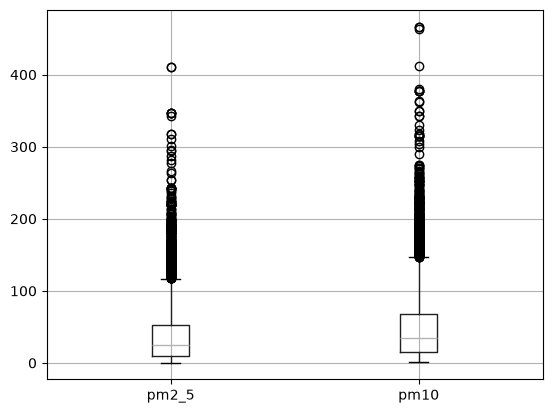

In [21]:
import matplotlib.pyplot as plt

df[["pm2_5", "pm10"]].boxplot()

plt.show()

In [22]:
print(df["location"].nunique())
print(df["location"].unique())

543
<StringArray>
[     'Adilabad',          'Agar',          'Agra',    'Ahmadnagar',
        'Aizawl',         'Ajmer',         'Akola',     'Alappuzha',
       'Aligarh',     'Alirajpur',
 ...
      'Warangal',        'Wardha',        'Washim', 'West Godavari',
         'Wokha',        'Yadgir',   'Yamunanagar',         'Yanam',
      'Yavatmal',     'Zunheboto']
Length: 543, dtype: str


In [23]:
print(df["region"].nunique())
print(df["region"].unique())

33
<StringArray>
[             'Andhra Pradesh',              'Madhya Pradesh',
               'Uttar Pradesh',                 'Maharashtra',
                     'Mizoram',                   'Rajasthan',
                      'Kerala',                 'Uttarakhand',
                     'Haryana',                     'Gujarat',
                      'Punjab',           'Jammu and Kashmir',
                      'Orissa',                       'Bihar',
                  'Tamil Nadu', 'Andaman and Nicobar Islands',
                   'Karnataka',                 'West Bengal',
                'Chhattisgarh',                       'Assam',
                   'Jharkhand',            'Himachal Pradesh',
                         'Goa',                  'Chandigarh',
                     'Manipur',      'Dadra and Nagar Haveli',
               'Daman and Diu',                     'Tripura',
                  'Puducherry',                 'Lakshadweep',
                    'Nagaland',       

In [24]:
print(
    df["respiratory_risk_proxy"].value_counts()
)

respiratory_risk_proxy
Low       4349
Medium    1976
High       232
Name: count, dtype: int64


In [25]:
print(
    set(df["respiratory_risk_proxy"].dropna())
    - {"Low", "Medium", "High"}
)

set()


In [27]:
print(
    df[
        (df["latitude"] < -90) |
        (df["latitude"] > 90)
    ]
)
print(
    df[
        (df["longitude"] < -180) |
        (df["longitude"] > 180)
    ]
)

Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []
Empty DataFrame
Columns: [timestamp, location, region, latitude, longitude, temperature_c, humidity, pm2_5, pm10, aqi_us_epa_index, hour, day, month, day_of_week, respiratory_risk_proxy, risk_basis, health_interpretation]
Index: []


In [28]:
df = df.sort_values(
    ["location", "timestamp"]
)

print(
    df[
        ["location", "timestamp"]
    ].head(20)
)

    location           timestamp
0   Adilabad 2023-08-29 10:45:00
1   Adilabad 2023-08-30 09:00:00
2   Adilabad 2023-08-31 05:30:00
3   Adilabad 2023-09-01 05:15:00
4   Adilabad 2023-09-02 05:30:00
5   Adilabad 2023-09-03 05:15:00
6   Adilabad 2023-09-04 05:15:00
7   Adilabad 2023-09-05 05:15:00
8   Adilabad 2023-09-06 05:00:00
9   Adilabad 2023-09-07 04:45:00
10  Adilabad 2023-09-08 04:30:00
11  Adilabad 2023-09-09 04:30:00
12      Agar 2023-08-29 10:45:00
13      Agar 2023-08-30 09:00:00
14      Agar 2023-08-31 05:30:00
15      Agar 2023-09-01 05:15:00
16      Agar 2023-09-02 05:30:00
17      Agar 2023-09-03 05:15:00
18      Agar 2023-09-04 05:15:00
19      Agar 2023-09-05 05:15:00


In [29]:
is_sorted = (
    df.groupby("location")["timestamp"]
      .apply(lambda x: x.is_monotonic_increasing)
)

print(is_sorted)

location
Adilabad       True
Agar           True
Agra           True
Ahmadnagar     True
Aizawl         True
               ... 
Yadgir         True
Yamunanagar    True
Yanam          True
Yavatmal       True
Zunheboto      True
Name: timestamp, Length: 543, dtype: bool


In [31]:
df["time_diff"] = (
    df.groupby("location")["timestamp"]
      .diff()
)

print(
    df["time_diff"].describe()
)
print(
    df["time_diff"]
    .value_counts()
    .head(20)
)

count                      6014
mean     0 days 23:15:48.935816
std      0 days 02:17:26.294222
min             0 days 00:00:00
25%             0 days 23:45:00
50%             0 days 23:45:00
75%             1 days 00:00:00
max             1 days 23:45:00
Name: time_diff, dtype: object
time_diff
1 days 00:00:00    2705
0 days 23:45:00    1982
0 days 20:30:00     521
0 days 22:00:00     323
0 days 22:15:00     220
1 days 00:15:00     130
0 days 23:30:00      65
0 days 00:15:00      36
0 days 20:15:00      15
0 days 00:00:00       8
0 days 20:45:00       7
1 days 23:45:00       1
1 days 23:30:00       1
Name: count, dtype: int64


In [32]:
numeric_cols = [
    "temperature_c",
    "humidity",
    "pm2_5",
    "pm10",
    "aqi_us_epa_index"
]

print(
    df[numeric_cols].corr()
)

                  temperature_c  humidity     pm2_5      pm10  \
temperature_c          1.000000 -0.368220  0.207571  0.252624   
humidity              -0.368220  1.000000 -0.113150 -0.212829   
pm2_5                  0.207571 -0.113150  1.000000  0.970843   
pm10                   0.252624 -0.212829  0.970843  1.000000   
aqi_us_epa_index       0.210656 -0.137448  0.907881  0.886889   

                  aqi_us_epa_index  
temperature_c             0.210656  
humidity                 -0.137448  
pm2_5                     0.907881  
pm10                      0.886889  
aqi_us_epa_index          1.000000  


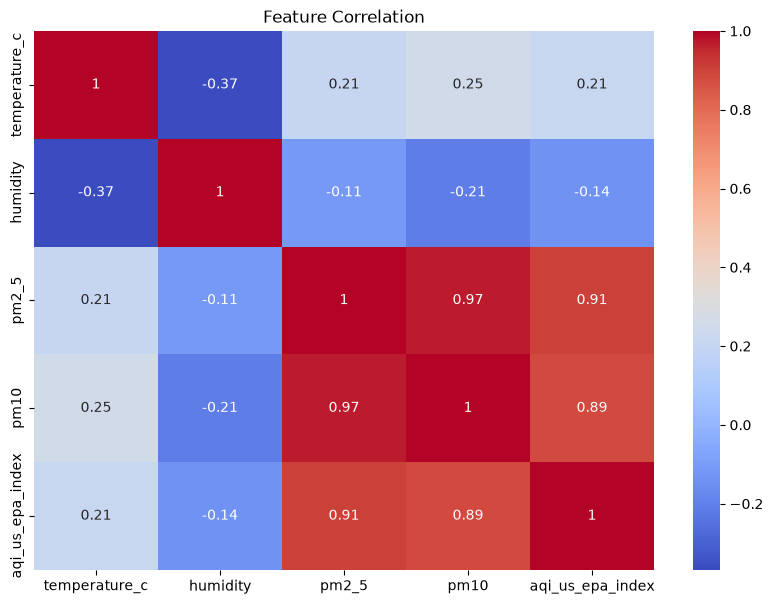

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [34]:
pd.crosstab(
    df["aqi_us_epa_index"],
    df["respiratory_risk_proxy"]
)

respiratory_risk_proxy,High,Low,Medium
aqi_us_epa_index,,,
1,0,2355,0
2,0,1994,0
3,0,0,924
4,0,0,1052
5,212,0,0
6,20,0,0


In [35]:
def data_quality_report(df):

    print("=" * 50)
    print("DATA QUALITY REPORT")
    print("=" * 50)

    print("\n1. Dataset Shape")
    print(df.shape)

    print("\n2. Missing Values")
    print(df.isnull().sum())

    print("\n3. Duplicate Rows")
    print(df.duplicated().sum())

    print("\n4. Data Types")
    print(df.dtypes)

    print("\n5. Numeric Summary")
    print(df.describe())

    print("\n6. Negative PM2.5")
    print((df["pm2_5"] < 0).sum())

    print("\n7. Negative PM10")
    print((df["pm10"] < 0).sum())

    print("\n8. Invalid Humidity")
    print(
        (
            (df["humidity"] < 0) |
            (df["humidity"] > 100)
        ).sum()
    )

    print("\n9. PM2.5 > PM10")
    print(
        (df["pm2_5"] > df["pm10"]).sum()
    )

    print("\n10. AQI Values")
    print(
        sorted(
            df["aqi_us_epa_index"]
            .dropna()
            .unique()
        )
    )

    print("\n11. Risk Labels")
    print(
        df["respiratory_risk_proxy"]
        .value_counts()
    )

    print("\n12. Locations")
    print(df["location"].nunique())

    print("\n13. Invalid Coordinates")
    print(
        (
            (df["latitude"] < -90) |
            (df["latitude"] > 90) |
            (df["longitude"] < -180) |
            (df["longitude"] > 180)
        ).sum()
    )

    print("=" * 50)


data_quality_report(df)

DATA QUALITY REPORT

1. Dataset Shape
(6557, 18)

2. Missing Values
timestamp                   0
location                    0
region                      0
latitude                    0
longitude                   0
temperature_c               0
humidity                    0
pm2_5                       0
pm10                        0
aqi_us_epa_index            0
hour                        0
day                         0
month                       0
day_of_week                 0
respiratory_risk_proxy      0
risk_basis                  0
health_interpretation       0
time_diff                 543
dtype: int64

3. Duplicate Rows
0

4. Data Types
timestamp                  datetime64[us]
location                              str
region                                str
latitude                          float64
longitude                         float64
temperature_c                     float64
humidity                            int64
pm2_5                             float64
pm10   